# 04_regression_pipeline

Notebook này triển khai bài toán **Regression** trên dữ liệu đã được tiền xử lý từ `orders_base_final` theo hướng **bám rubric, khớp báo cáo và sẵn sàng tích hợp UI**.

## Mục tiêu kỹ thuật
- Đọc dữ liệu processed từ notebook 02.
- Dùng target thống nhất với code hiện tại: `payment_value_sum`.
- Dựng **Scikit-learn Pipeline** đầy đủ:
  - `SimpleImputer`
  - `StandardScaler`
  - `OneHotEncoder`
  - `ColumnTransformer`
  - `SelectKBest(f_regression)`
- So sánh đúng **3 mô hình bắt buộc**:
  - `LinearRegression`
  - `DecisionTreeRegressor`
  - `RandomForestRegressor`
- Đánh giá bằng:
  - `RMSE`
  - `MAE`
  - `R²`
  - `Actual vs Predicted`
  - `Residual analysis`
- Có:
  - **Cross-validation cho toàn bộ 3 model**
  - **GridSearchCV gọn cho model baseline tốt nhất**
  - **Save/Load artifact**
  - **Refit model deployment trên toàn bộ dữ liệu đã gán nhãn**

## Ghi chú đồng bộ với báo cáo
- Notebook regression này dùng `SelectKBest(f_regression)` thay vì `chi2`.
- Regression được diễn giải là **ước lượng giá trị đơn hàng từ thông tin có thể biết tại thời điểm đặt hàng**.
- Để tránh dự đoán bùng nổ ở `LinearRegression`, notebook cho phép **không dùng log-target cho riêng LinearRegression**, trong khi vẫn giữ `log1p/expm1` cho tree models nếu bật `USE_LOG_TARGET = True`.

> Sau khi chỉnh sửa notebook, hãy **Run All** để đồng bộ lại toàn bộ output, ảnh, CSV và model artifacts.


## Cell 1: Import thư viện và thiết lập môi trường


In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import time
import json
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, Markdown

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split, cross_validate, GridSearchCV, KFold
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor


## Cell 2 Khai báo cấu hình chung cho notebook regression

In [2]:
# =========================
# CONFIG
# =========================
BASE_DIR = Path("..")
PROCESSED_DIR = BASE_DIR / "data" / "processed"
ARTIFACT_DIR = BASE_DIR / "artifacts"

MODEL_DIR = ARTIFACT_DIR / "models"
METRIC_DIR = ARTIFACT_DIR / "metrics"
PLOT_DIR = ARTIFACT_DIR / "plots"
PRED_DIR = ARTIFACT_DIR / "predictions"

for folder in [MODEL_DIR, METRIC_DIR, PLOT_DIR, PRED_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.20

# CV / tuning: giữ gọn để không quá lâu
COMPARE_CV_FOLDS = 3
TUNING_CV_FOLDS = 3
MAX_SELECTED_FEATURES = 60
RUN_GRID_SEARCH = True
GRID_VERBOSE = 1

# Deployment
TARGET_COL = "payment_value_sum"
USE_LOG_TARGET = True
USE_LOG_TARGET_FOR_LINEAR = False
REFIT_FINAL_ON_FULL_DATA = True

print("PROCESSED_DIR:", PROCESSED_DIR)
print("ARTIFACT_DIR:", ARTIFACT_DIR)
print("TARGET_COL:", TARGET_COL)
print("USE_LOG_TARGET:", USE_LOG_TARGET)
print("USE_LOG_TARGET_FOR_LINEAR:", USE_LOG_TARGET_FOR_LINEAR)
print("COMPARE_CV_FOLDS:", COMPARE_CV_FOLDS)
print("TUNING_CV_FOLDS:", TUNING_CV_FOLDS)
print("RUN_GRID_SEARCH:", RUN_GRID_SEARCH)
print("REFIT_FINAL_ON_FULL_DATA:", REFIT_FINAL_ON_FULL_DATA)


PROCESSED_DIR: ..\data\processed
ARTIFACT_DIR: ..\artifacts
TARGET_COL: payment_value_sum
USE_LOG_TARGET: True
USE_LOG_TARGET_FOR_LINEAR: False
COMPARE_CV_FOLDS: 3
TUNING_CV_FOLDS: 3
RUN_GRID_SEARCH: True
REFIT_FINAL_ON_FULL_DATA: True


## CEll 3: Đọc dữ liệu đầu vào đã được tiền xử lý

In [3]:
# =========================
# LOAD DATA
# =========================
parquet_path = PROCESSED_DIR / "orders_base_final.parquet"
csv_path = PROCESSED_DIR / "orders_base_final.csv"

if parquet_path.exists():
    df = pd.read_parquet(parquet_path)
elif csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    raise FileNotFoundError(
        "Không tìm thấy orders_base_final.parquet hoặc orders_base_final.csv trong data/processed"
    )

display(Markdown("### 5 dòng đầu của dữ liệu processed"))
display(df.head())

print("Shape:", df.shape)
print("Số cột:", df.shape[1])


### 5 dòng đầu của dữ liệu processed

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,purchase_month,purchase_day,purchase_hour,purchase_dayofweek,purchase_month_period,is_late_delivery,review_label,time_issue_approval_before_purchase,time_issue_carrier_before_purchase,time_issue_customer_before_carrier
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,10,2,10,0,2017-10,0,1,False,False,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,barreiras,...,7,24,20,1,2018-07,0,1,False,False,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,8,8,8,2,2018-08,0,1,False,False,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,11,18,19,5,2017-11,0,1,False,False,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,2,13,21,1,2018-02,0,1,False,False,False


Shape: (99441, 52)
Số cột: 52


## Cell 4: Kiểm tra danh sách cột trong dataset

In [4]:
# =========================
# KIỂM TRA CỘT
# =========================
display(Markdown("### Danh sách cột"))
print(sorted(df.columns.tolist()))


### Danh sách cột

['approval_time_hours', 'basket_value', 'customer_city', 'customer_geo_lat_mean', 'customer_geo_lng_mean', 'customer_id', 'customer_state', 'customer_unique_id', 'customer_zip_code_prefix', 'delivery_delay_days', 'delivery_time_days', 'freight_value_sum', 'has_comment', 'is_late_delivery', 'item_count', 'main_category', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_id', 'order_purchase_timestamp', 'order_status', 'payment_installments_max', 'payment_sequential_max', 'payment_type_mode', 'payment_value_sum', 'price_mean', 'price_sum', 'purchase_day', 'purchase_dayofweek', 'purchase_hour', 'purchase_month', 'purchase_month_period', 'purchase_to_carrier_days', 'purchase_year', 'review_comment_length', 'review_comment_message', 'review_count', 'review_label', 'review_response_hours', 'review_score', 'seller_city_mode', 'seller_geo_lat_mean', 'seller_geo_lng_mean', 'seller_state_mode', 'shipping_time_days', 'tim

## Cell 5: Chuẩn hóa và làm sạch biến mục tiêu regression

In [5]:
# =========================
# CHUẨN HÓA TARGET
# =========================
df = df.copy()

if TARGET_COL not in df.columns:
    raise KeyError(f"Không tìm thấy target column: {TARGET_COL}")

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")
df = df.dropna(subset=[TARGET_COL]).copy()

# target tiền phải không âm
df = df[df[TARGET_COL] >= 0].copy()

display(Markdown(f"### Thống kê mô tả của target: {TARGET_COL}"))
display(df[TARGET_COL].describe())

print("Skewness target gốc:", round(df[TARGET_COL].skew(), 4))
print("Số dòng còn lại sau khi làm sạch target:", len(df))


### Thống kê mô tả của target: payment_value_sum

count    99440.000000
mean       160.990267
std        221.951257
min          0.000000
25%         62.010000
50%        105.290000
75%        176.970000
max      13664.080000
Name: payment_value_sum, dtype: float64

Skewness target gốc: 9.1502
Số dòng còn lại sau khi làm sạch target: 99440


## Cell 6: Khảo sát phân phối của biến mục tiêu

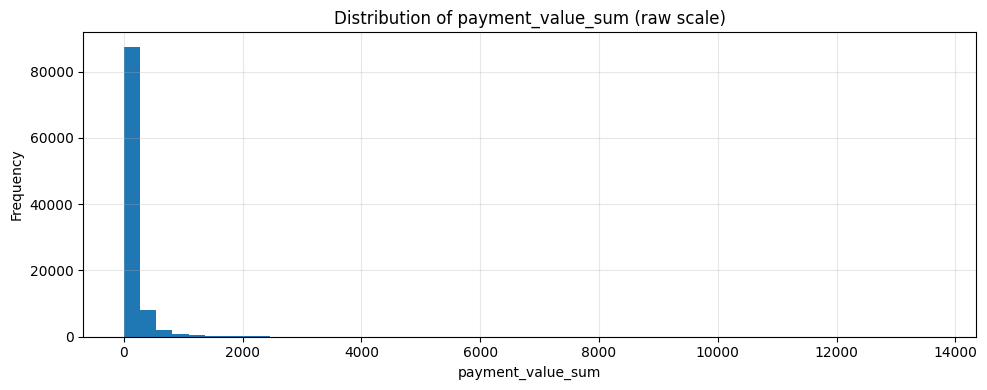

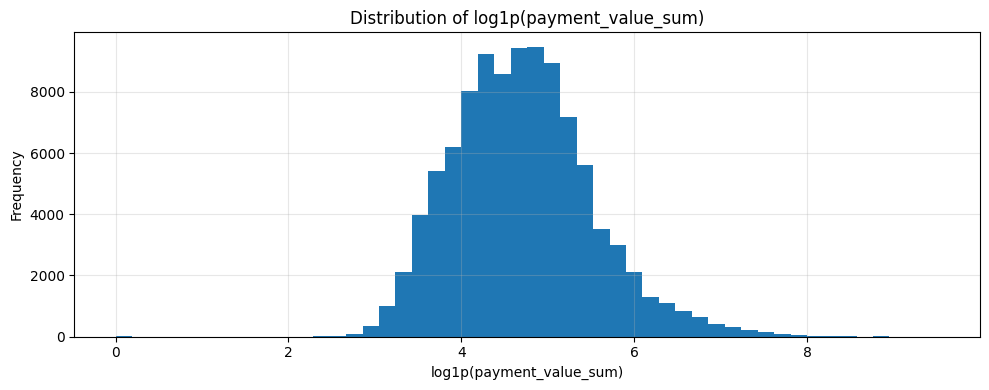

In [6]:
# =========================
# PHÂN PHỐI TARGET
# =========================
plt.figure(figsize=(10, 4))
plt.hist(df[TARGET_COL], bins=50)
plt.title(f"Distribution of {TARGET_COL} (raw scale)")
plt.xlabel(TARGET_COL)
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

if USE_LOG_TARGET:
    plt.figure(figsize=(10, 4))
    plt.hist(np.log1p(df[TARGET_COL]), bins=50)
    plt.title(f"Distribution of log1p({TARGET_COL})")
    plt.xlabel(f"log1p({TARGET_COL})")
    plt.ylabel("Frequency")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


## Cell 7: Chọn feature đầu vào cho baseline regression

In [7]:
# =========================
# CHỌN FEATURE CHO BASELINE REGRESSION
# - Ưu tiên feature logic hơn là metric "ảo"
# - Loại bỏ direct leakage và các biến hậu giao hàng / hậu review
# =========================
numeric_candidates = [
    "item_count",
    "unique_products",
    "unique_sellers",
    "price_mean",
    "payment_installments_max",
    "purchase_year",
    "purchase_month",
    "purchase_day",
    "purchase_hour",
    "purchase_dayofweek"
]

categorical_candidates = [
    "customer_state",
    "main_category",
    "payment_type_mode"
]

blocked_cols = {
    TARGET_COL,
    "price_sum",
    "freight_value_sum",
    "basket_value",
    "review_score",
    "review_count",
    "review_comment_length",
    "has_comment",
    "review_comment_message",
    "delivery_time_days",
    "delivery_delay_days",
    "shipping_time_days",
    "purchase_to_carrier_days",
    "approval_time_hours",
    "is_late_delivery",
    "order_status",
    "customer_city",
    "purchase_month_period",
    "order_id",
    "customer_id",
    "customer_unique_id",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
}

numeric_features = [
    col for col in numeric_candidates
    if col in df.columns and col not in blocked_cols
]

categorical_features = [
    col for col in categorical_candidates
    if col in df.columns and col not in blocked_cols
]

feature_cols = numeric_features + categorical_features

display(Markdown("### Numeric features"))
print(numeric_features)

display(Markdown("### Categorical features"))
print(categorical_features)

display(Markdown("### Tổng số feature baseline regression"))
print(len(feature_cols))


### Numeric features

['item_count', 'unique_products', 'unique_sellers', 'price_mean', 'payment_installments_max', 'purchase_year', 'purchase_month', 'purchase_day', 'purchase_hour', 'purchase_dayofweek']


### Categorical features

['customer_state', 'main_category', 'payment_type_mode']


### Tổng số feature baseline regression

13


## Cell 8: Tạo tập dữ liệu regression hoàn chỉnh

In [8]:
# =========================
# TẠO DATASET CHO BASELINE REGRESSION
# =========================
regression_df = df[feature_cols + [TARGET_COL]].copy()

X = regression_df.drop(columns=[TARGET_COL])
y = regression_df[TARGET_COL].astype(float)

print("X shape:", X.shape)
print("y shape:", y.shape)

display(Markdown("### Missing values trong X trước split"))
missing_before_split = X.isnull().sum()
missing_before_split = missing_before_split[missing_before_split > 0].sort_values(ascending=False)
display(missing_before_split.head(20))


X shape: (99440, 13)
y shape: (99440,)


### Missing values trong X trước split

item_count         775
unique_products    775
unique_sellers     775
price_mean         775
dtype: int64

## Cell 9: Chia dữ liệu train/test

In [9]:
# =========================
# TRAIN / TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape :", X_test.shape, y_test.shape)


Train shape: (79552, 13) (79552,)
Test shape : (19888, 13) (19888,)


## Cell 10: Tạo các hàm hỗ trợ cho preprocessing và target transform

In [10]:
# =========================
# HELPER FUNCTIONS
# =========================
def make_ohe():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

def safe_relpath(path_obj):
    path_obj = Path(path_obj)
    try:
        return Path(path_obj).relative_to(BASE_DIR).as_posix()
    except Exception:
        return str(path_obj).replace("\\", "/")

def use_log_target_for_model(model_name: str) -> bool:
    if not USE_LOG_TARGET:
        return False
    if model_name == "LinearRegression" and not USE_LOG_TARGET_FOR_LINEAR:
        return False
    return True

def model_param_prefix(model_name: str) -> str:
    return "regressor__model__" if use_log_target_for_model(model_name) else "model__"

def make_regression_cv():
    return KFold(n_splits=COMPARE_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

def make_tuning_cv():
    return KFold(n_splits=TUNING_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)


## Cell 11: Xây dựng preprocessor cho baseline regression

In [11]:
# =========================
# PREPROCESSOR CHO BASELINE REGRESSION
# =========================
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", make_ohe())
])

baseline_preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
], remainder="drop")

display(Markdown("### Fit thử preprocessor để xác định số feature sau transform"))
X_train_pre = baseline_preprocessor.fit_transform(X_train)
X_test_pre = baseline_preprocessor.transform(X_test)

print("Transformed train shape:", X_train_pre.shape)
print("Transformed test shape :", X_test_pre.shape)


### Fit thử preprocessor để xác định số feature sau transform

Transformed train shape: (79552, 116)
Transformed test shape : (19888, 116)


## Cell 12: Lấy tên feature sau preprocessing

In [12]:
# =========================
# FEATURE NAMES SAU TRANSFORM
# =========================
feature_names_after_preprocess = baseline_preprocessor.get_feature_names_out().tolist()
k_best = min(MAX_SELECTED_FEATURES, len(feature_names_after_preprocess))

print("Số feature sau preprocess:", len(feature_names_after_preprocess))
print("k_best được dùng:", k_best)

display(Markdown("### 20 feature đầu tiên sau preprocess"))
print(feature_names_after_preprocess[:20])


Số feature sau preprocess: 116
k_best được dùng: 60


### 20 feature đầu tiên sau preprocess

['num__item_count', 'num__unique_products', 'num__unique_sellers', 'num__price_mean', 'num__payment_installments_max', 'num__purchase_year', 'num__purchase_month', 'num__purchase_day', 'num__purchase_hour', 'num__purchase_dayofweek', 'cat__customer_state_AC', 'cat__customer_state_AL', 'cat__customer_state_AM', 'cat__customer_state_AP', 'cat__customer_state_BA', 'cat__customer_state_CE', 'cat__customer_state_DF', 'cat__customer_state_ES', 'cat__customer_state_GO', 'cat__customer_state_MA']


## Cell 13: Kiểm tra nhanh feature selection bằng f_regression

In [13]:
# =========================
# XEM NHANH FEATURE SELECTION TRƯỚC KHI TRAIN
# - Dùng target gốc để đọc score dễ hiểu hơn trong report
# =========================
selector_probe = SelectKBest(score_func=f_regression, k=k_best)
selector_probe.fit(X_train_pre, y_train)

probe_scores = pd.DataFrame({
    "feature": feature_names_after_preprocess,
    "score": np.nan_to_num(selector_probe.scores_, nan=0.0, posinf=0.0, neginf=0.0)
}).sort_values("score", ascending=False)

display(Markdown("### Top feature theo f_regression"))
display(probe_scores.head(20))


### Top feature theo f_regression

,feature,score
3,num__price_mean,365970.130561
4,num__payment_installments_max,8866.717105
51,cat__main_category_computers,3599.535091
0,num__item_count,2858.303164
110,cat__main_category_watches_gifts,502.008538
82,cat__main_category_home_appliances_2,440.161758
1,num__unique_products,431.114153
35,cat__customer_state_SP,352.893709
103,cat__main_category_small_appliances_home_oven_...,339.740884
102,cat__main_category_small_appliances,333.060696


## Cell 14: Xây dựng hàm tạo estimator hoàn chỉnh cho regression

In [14]:
# =========================
# HÀM BUILD ESTIMATOR
# =========================
def build_regression_estimator(model_name, model):
    base_pipeline = Pipeline([
        ("preprocessor", ColumnTransformer([
            ("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), numeric_features),
            ("cat", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_ohe())
            ]), categorical_features)
        ], remainder="drop")),
        ("selector", SelectKBest(score_func=f_regression, k=k_best)),
        ("model", model)
    ])

    if use_log_target_for_model(model_name):
        return TransformedTargetRegressor(
            regressor=base_pipeline,
            func=np.log1p,
            inverse_func=np.expm1,
            check_inverse=False
        )

    return base_pipeline


## Cell 15: Khai báo các mô hình baseline

In [15]:
# =========================
# ĐỊNH NGHĨA CÁC MODEL BASELINE
# =========================
models = {
    "LinearRegression": LinearRegression(),
    "DecisionTreeRegressor": DecisionTreeRegressor(
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=RANDOM_STATE
    ),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_split=5,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )
}

display(Markdown("### Cấu hình baseline models"))
for model_name, model in models.items():
    print(model_name, "->", model)


### Cấu hình baseline models

LinearRegression -> LinearRegression()
DecisionTreeRegressor -> DecisionTreeRegressor(min_samples_leaf=2, min_samples_split=5, random_state=42)
RandomForestRegressor -> RandomForestRegressor(min_samples_leaf=2, min_samples_split=5, n_estimators=300,
                      n_jobs=-1, random_state=42)


## Cell 16: Xây dựng hàm đánh giá một mô hình regression

In [16]:
# =========================
# HÀM EVALUATE MODEL
# =========================
def evaluate_regressor(name, model, X_train, y_train, X_test, y_test):
    estimator = build_regression_estimator(name, model)

    start = time.time()
    estimator.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = estimator.predict(X_test)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.clip(y_pred, 0, None)

    result = {
        "model": name,
        "mae": mean_absolute_error(y_test, y_pred),
        "mse": mean_squared_error(y_test, y_pred),
        "rmse": math.sqrt(mean_squared_error(y_test, y_pred)),
        "r2": r2_score(y_test, y_pred),
        "train_time_sec": train_time,
        "use_log_target": use_log_target_for_model(name)
    }

    pred_df = pd.DataFrame({
        "y_true": np.asarray(y_test, dtype=float),
        "y_pred": y_pred
    })
    pred_df["residual"] = pred_df["y_true"] - pred_df["y_pred"]
    pred_df["abs_error"] = np.abs(pred_df["residual"])

    return estimator, result, pred_df


## Cell 17: Train và đánh giá toàn bộ các model baseline

In [17]:
# =========================
# TRAIN & EVALUATE TẤT CẢ MODEL BASELINE
# =========================
baseline_results = []
trained_estimators = {}
test_predictions = {}

for model_name, model in models.items():
    print(f"\n===== {model_name} =====")
    fitted_estimator, metrics_dict, pred_df = evaluate_regressor(
        model_name, model, X_train, y_train, X_test, y_test
    )

    baseline_results.append(metrics_dict)
    trained_estimators[model_name] = fitted_estimator
    test_predictions[model_name] = pred_df

    print(pd.Series(metrics_dict))



===== LinearRegression =====
model             LinearRegression
mae                      17.166904
mse                    3134.433066
rmse                     55.986008
r2                        0.929253
train_time_sec            0.941976
use_log_target               False
dtype: object

===== DecisionTreeRegressor =====
model             DecisionTreeRegressor
mae                            9.043521
mse                         1083.350072
rmse                          32.914284
r2                             0.975548
train_time_sec                 1.160159
use_log_target                     True
dtype: object

===== RandomForestRegressor =====
model             RandomForestRegressor
mae                            8.322734
mse                         1058.711635
rmse                          32.537849
r2                             0.976104
train_time_sec                21.514494
use_log_target                     True
dtype: object


## Cell 18: Tổng hợp bảng kết quả baseline

In [18]:
# =========================
# BẢNG TỔNG HỢP KẾT QUẢ BASELINE
# =========================
baseline_metrics_df = pd.DataFrame(baseline_results).sort_values(
    by=["rmse", "mae", "r2", "train_time_sec"],
    ascending=[True, True, False, True]
).reset_index(drop=True)

display(Markdown("### Baseline regression metrics"))
display(baseline_metrics_df)

baseline_metrics_path = METRIC_DIR / "regression_metrics_baseline.csv"
baseline_metrics_df.to_csv(baseline_metrics_path, index=False)

print("Đã lưu:", baseline_metrics_path)


### Baseline regression metrics

,model,mae,mse,rmse,r2,train_time_sec,use_log_target
0,RandomForestRegressor,8.322734,1058.711635,32.537849,0.976104,21.514494,True
1,DecisionTreeRegressor,9.043521,1083.350072,32.914284,0.975548,1.160159,True
2,LinearRegression,17.166904,3134.433066,55.986008,0.929253,0.941976,False


Đã lưu: ..\artifacts\metrics\regression_metrics_baseline.csv


## Cell 19: Chọn mô hình baseline tốt nhất

In [19]:
# =========================
# CHỌN MODEL BASELINE TỐT NHẤT
# =========================
best_model_name = baseline_metrics_df.iloc[0]["model"]
best_model_estimator = trained_estimators[best_model_name]
best_pred_df = test_predictions[best_model_name].copy()

print("Best baseline regressor:", best_model_name)

display(Markdown(f"### Kết quả holdout test - {best_model_name}"))
display(best_pred_df.head())

best_metrics_row = baseline_metrics_df.iloc[[0]].copy()
display(Markdown("### Metrics của best baseline model"))
display(best_metrics_row)

# selected_* sẽ có thể được update sau tuning
selected_eval_model_name = best_model_name
selected_eval_estimator = best_model_estimator
selected_pred_df = best_pred_df.copy()
selected_metrics_row = best_metrics_row.copy()
selected_best_params = None
selected_model_source = "baseline"
selected_is_tuned = False
grid_search_results = None
grid_search_path = None
tuning_compare_path = None


Best baseline regressor: RandomForestRegressor


### Kết quả holdout test - RandomForestRegressor

,y_true,y_pred,residual,abs_error
0,249.08,256.486722,-7.406722,7.406722
1,125.42,127.506778,-2.086778,2.086778
2,30.10,30.264920,-0.164920,0.164920
3,256.05,256.557180,-0.507180,0.507180
4,128.90,134.587678,-5.687678,5.687678


### Metrics của best baseline model

,model,mae,mse,rmse,r2,train_time_sec,use_log_target
0,RandomForestRegressor,8.322734,1058.711635,32.537849,0.976104,21.514494,True


## Cell 19B: Grid Search gọn cho baseline model tốt nhất

- Chỉ tune **model baseline tốt nhất** để giữ thời gian hợp lý.
- Dùng **grid nhỏ + CV=3**.
- Sau tuning sẽ **chỉ chọn model tuned** nếu RMSE tốt hơn baseline trên holdout test.


In [20]:
# =========================
# GRID SEARCH GỌN CHO BASELINE MODEL TỐT NHẤT
# =========================
def build_tuning_setup(best_model_name):
    prefix = model_param_prefix(best_model_name)

    if best_model_name == "LinearRegression":
        base_model = LinearRegression()
        estimator = build_regression_estimator(best_model_name, base_model)
        param_grid = {
            f"{prefix}fit_intercept": [True, False]
        }

    elif best_model_name == "DecisionTreeRegressor":
        base_model = DecisionTreeRegressor(random_state=RANDOM_STATE)
        estimator = build_regression_estimator(best_model_name, base_model)
        param_grid = {
            f"{prefix}max_depth": [12, 18, None],
            f"{prefix}min_samples_leaf": [1, 2, 5]
        }

    else:
        base_model = RandomForestRegressor(
            n_jobs=-1,
            random_state=RANDOM_STATE
        )
        estimator = build_regression_estimator(best_model_name, base_model)
        param_grid = {
            f"{prefix}n_estimators": [180, 260],
            f"{prefix}max_depth": [None, 18],
            f"{prefix}min_samples_leaf": [1, 2]
        }

    return estimator, param_grid

if RUN_GRID_SEARCH:
    search_estimator, param_grid = build_tuning_setup(best_model_name)

    grid = GridSearchCV(
        estimator=search_estimator,
        param_grid=param_grid,
        scoring="neg_root_mean_squared_error",
        cv=make_tuning_cv(),
        n_jobs=1,
        verbose=GRID_VERBOSE,
        refit=True
    )

    tuning_start = time.time()
    grid.fit(X_train, y_train)
    tuning_time_sec = time.time() - tuning_start

    tuned_best_estimator = grid.best_estimator_
    tuned_pred = np.asarray(tuned_best_estimator.predict(X_test), dtype=float)
    tuned_pred = np.clip(tuned_pred, 0, None)

    grid_search_results = pd.DataFrame([{
        "baseline_model": best_model_name,
        "tuned_model_label": f"{best_model_name}_TUNED",
        "cv_best_rmse": float(-grid.best_score_),
        "holdout_mae": mean_absolute_error(y_test, tuned_pred),
        "holdout_mse": mean_squared_error(y_test, tuned_pred),
        "holdout_rmse": math.sqrt(mean_squared_error(y_test, tuned_pred)),
        "holdout_r2": r2_score(y_test, tuned_pred),
        "tuning_time_sec": tuning_time_sec,
        "best_params": json.dumps(grid.best_params_, ensure_ascii=False)
    }])

    display(Markdown("### Grid Search result"))
    display(grid_search_results)

    grid_search_path = METRIC_DIR / "regression_grid_search_best_model.csv"
    grid_search_results.to_csv(grid_search_path, index=False)
    print("Đã lưu:", grid_search_path)

    tuned_metrics_row = pd.DataFrame([{
        "model": f"{best_model_name}_TUNED",
        "mae": grid_search_results.loc[0, "holdout_mae"],
        "mse": grid_search_results.loc[0, "holdout_mse"],
        "rmse": grid_search_results.loc[0, "holdout_rmse"],
        "r2": grid_search_results.loc[0, "holdout_r2"],
        "train_time_sec": grid_search_results.loc[0, "tuning_time_sec"],
        "use_log_target": use_log_target_for_model(best_model_name)
    }])

    tuning_comparison_df = pd.concat([
        best_metrics_row.assign(stage="baseline"),
        tuned_metrics_row.assign(stage="tuned")
    ], ignore_index=True)

    tuning_comparison_df["selected_for_deployment"] = False

    baseline_rmse = float(best_metrics_row.iloc[0]["rmse"])
    baseline_mae = float(best_metrics_row.iloc[0]["mae"])
    tuned_rmse = float(tuned_metrics_row.iloc[0]["rmse"])
    tuned_mae = float(tuned_metrics_row.iloc[0]["mae"])

    tuned_is_better = (
        (tuned_rmse < baseline_rmse - 0.01) or
        (abs(tuned_rmse - baseline_rmse) <= 0.01 and tuned_mae <= baseline_mae)
    )

    if tuned_is_better:
        selected_eval_model_name = f"{best_model_name}_TUNED"
        selected_eval_estimator = tuned_best_estimator
        selected_pred_df = pd.DataFrame({
            "y_true": np.asarray(y_test, dtype=float),
            "y_pred": tuned_pred
        })
        selected_pred_df["residual"] = selected_pred_df["y_true"] - selected_pred_df["y_pred"]
        selected_pred_df["abs_error"] = np.abs(selected_pred_df["residual"])
        selected_metrics_row = tuned_metrics_row.copy()
        selected_best_params = grid.best_params_
        selected_model_source = "tuned"
        selected_is_tuned = True
        tuning_comparison_df.loc[tuning_comparison_df["stage"].eq("tuned"), "selected_for_deployment"] = True
    else:
        tuning_comparison_df.loc[tuning_comparison_df["stage"].eq("baseline"), "selected_for_deployment"] = True

    display(Markdown("### So sánh baseline vs tuned"))
    display(tuning_comparison_df)

    tuning_compare_path = METRIC_DIR / "regression_tuning_comparison.csv"
    tuning_comparison_df.to_csv(tuning_compare_path, index=False)
    print("Đã lưu:", tuning_compare_path)

else:
    print("RUN_GRID_SEARCH = False -> bỏ qua bước tuning")


Fitting 3 folds for each of 8 candidates, totalling 24 fits


### Grid Search result

,baseline_model,tuned_model_label,cv_best_rmse,holdout_mae,holdout_mse,holdout_rmse,holdout_r2,tuning_time_sec,best_params
0,RandomForestRegressor,RandomForestRegressor_TUNED,56.244735,8.243744,1012.937477,31.826679,0.977137,199.364374,"{""regressor__model__max_depth"": 18, ""regressor..."


Đã lưu: ..\artifacts\metrics\regression_grid_search_best_model.csv


### So sánh baseline vs tuned

,model,mae,mse,rmse,r2,train_time_sec,use_log_target,stage,selected_for_deployment
0,RandomForestRegressor,8.322734,1058.711635,32.537849,0.976104,21.514494,True,baseline,False
1,RandomForestRegressor_TUNED,8.243744,1012.937477,31.826679,0.977137,199.364374,True,tuned,True


Đã lưu: ..\artifacts\metrics\regression_tuning_comparison.csv


## Cell 20: Vẽ biểu đồ Actual vs Predicted cho model được chọn

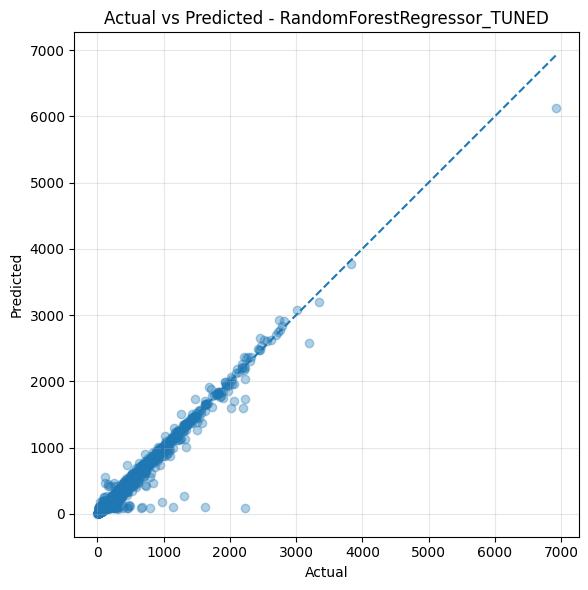

Đã lưu: ..\artifacts\plots\actual_vs_pred_selected_regressor.png


### Metrics của model được chọn

,model,mae,mse,rmse,r2,train_time_sec,use_log_target
0,RandomForestRegressor_TUNED,8.243744,1012.937477,31.826679,0.977137,199.364374,True


In [21]:
# =========================
# ACTUAL VS PREDICTED
# =========================
plt.figure(figsize=(6, 6))
plt.scatter(selected_pred_df["y_true"], selected_pred_df["y_pred"], alpha=0.35)
min_val = min(selected_pred_df["y_true"].min(), selected_pred_df["y_pred"].min())
max_val = max(selected_pred_df["y_true"].max(), selected_pred_df["y_pred"].max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.title(f"Actual vs Predicted - {selected_eval_model_name}")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(alpha=0.3)
plt.tight_layout()

actual_vs_pred_path = PLOT_DIR / "actual_vs_pred_selected_regressor.png"
plt.savefig(actual_vs_pred_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu:", actual_vs_pred_path)
display(Markdown("### Metrics của model được chọn"))
display(selected_metrics_row)


## Cell 21: Phân tích residual của model được chọn

### Residual summary

count    19888.000000
mean         1.054739
std         31.809997
min       -440.030515
25%         -3.853245
50%         -0.986450
75%          2.261051
max       2149.482294
Name: residual, dtype: float64

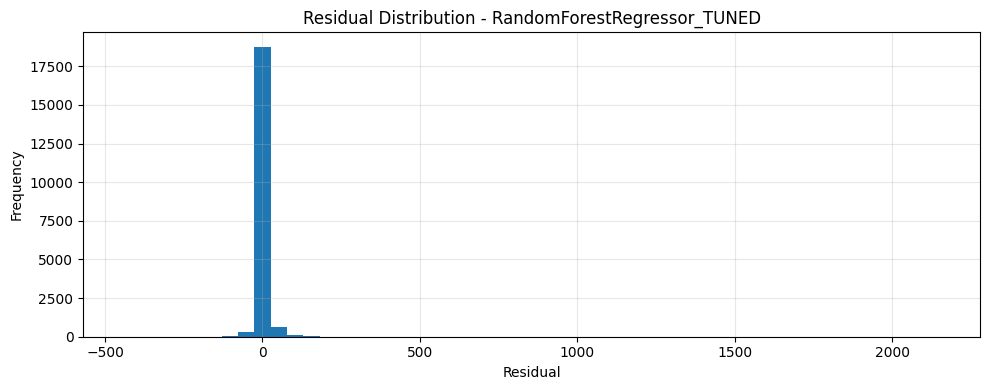

Đã lưu: ..\artifacts\plots\residual_hist_selected_regressor.png


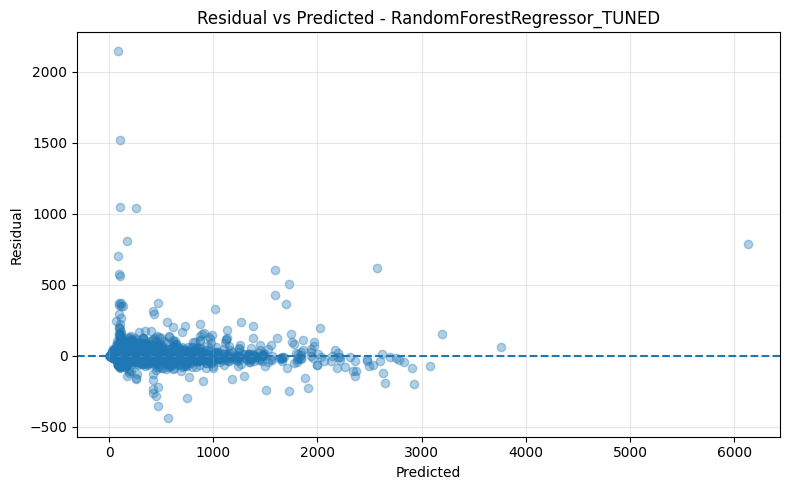

Đã lưu: ..\artifacts\plots\residual_vs_pred_selected_regressor.png


In [22]:
# =========================
# RESIDUAL ANALYSIS
# =========================
display(Markdown("### Residual summary"))
display(selected_pred_df["residual"].describe())

plt.figure(figsize=(10, 4))
plt.hist(selected_pred_df["residual"], bins=50)
plt.title(f"Residual Distribution - {selected_eval_model_name}")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.tight_layout()

residual_hist_path = PLOT_DIR / "residual_hist_selected_regressor.png"
plt.savefig(residual_hist_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu:", residual_hist_path)

plt.figure(figsize=(8, 5))
plt.scatter(selected_pred_df["y_pred"], selected_pred_df["residual"], alpha=0.35)
plt.axhline(0, linestyle="--")
plt.title(f"Residual vs Predicted - {selected_eval_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.tight_layout()

residual_vs_pred_path = PLOT_DIR / "residual_vs_pred_selected_regressor.png"
plt.savefig(residual_vs_pred_path, dpi=150, bbox_inches="tight")
plt.show()

print("Đã lưu:", residual_vs_pred_path)


## Cell 22: Cross-validation cho cả 3 model và model được chọn

In [23]:
# =========================
# CROSS-VALIDATION
# - CV trên cả 3 baseline models để bám rubric Utilities & Evaluation
# - Nếu model được chọn là tuned thì chạy thêm CV riêng cho config đã chọn
# =========================
cv_rows = []

for model_name, model in models.items():
    cv_scores = cross_validate(
        build_regression_estimator(model_name, clone(model)),
        X_train,
        y_train,
        cv=make_regression_cv(),
        scoring={
            "mae": "neg_mean_absolute_error",
            "mse": "neg_mean_squared_error",
            "r2": "r2"
        },
        n_jobs=1,
        return_train_score=False
    )

    cv_rows.append({
        "model": model_name,
        "cv_mae_mean": float((-cv_scores["test_mae"]).mean()),
        "cv_mae_std": float((-cv_scores["test_mae"]).std()),
        "cv_rmse_mean": float(np.sqrt(-cv_scores["test_mse"]).mean()),
        "cv_rmse_std": float(np.sqrt(-cv_scores["test_mse"]).std()),
        "cv_r2_mean": float(cv_scores["test_r2"].mean()),
        "cv_r2_std": float(cv_scores["test_r2"].std()),
        "use_log_target": use_log_target_for_model(model_name)
    })

cv_all_models_df = pd.DataFrame(cv_rows).sort_values(
    by=["cv_rmse_mean", "cv_mae_mean", "cv_r2_mean"],
    ascending=[True, True, False]
).reset_index(drop=True)

display(Markdown("### Cross-validation comparison - all baseline models"))
display(cv_all_models_df)

cv_all_models_path = METRIC_DIR / "regression_cv_all_models.csv"
cv_all_models_df.to_csv(cv_all_models_path, index=False)
print("Đã lưu:", cv_all_models_path)

selected_cv_scores = cross_validate(
    clone(selected_eval_estimator),
    X_train,
    y_train,
    cv=make_regression_cv(),
    scoring={
        "mae": "neg_mean_absolute_error",
        "mse": "neg_mean_squared_error",
        "r2": "r2"
    },
    n_jobs=1,
    return_train_score=False
)

cv_summary = pd.DataFrame({
    "metric": ["mae", "rmse", "r2"],
    "mean": [
        float((-selected_cv_scores["test_mae"]).mean()),
        float(np.sqrt(-selected_cv_scores["test_mse"]).mean()),
        float(selected_cv_scores["test_r2"].mean())
    ],
    "std": [
        float((-selected_cv_scores["test_mae"]).std()),
        float(np.sqrt(-selected_cv_scores["test_mse"]).std()),
        float(selected_cv_scores["test_r2"].std())
    ],
    "model": [selected_eval_model_name] * 3
})

display(Markdown(f"### Cross-validation summary - selected model ({selected_eval_model_name})"))
display(cv_summary)

cv_summary_path = METRIC_DIR / "regression_cv_summary_selected_model.csv"
cv_summary.to_csv(cv_summary_path, index=False)
print("Đã lưu:", cv_summary_path)


### Cross-validation comparison - all baseline models

,model,cv_mae_mean,cv_mae_std,cv_rmse_mean,cv_rmse_std,cv_r2_mean,cv_r2_std,use_log_target
0,RandomForestRegressor,9.006527,0.586267,57.758744,26.069068,0.927123,0.055445,True
1,DecisionTreeRegressor,10.254331,0.761199,57.970984,22.991045,0.928626,0.047174,True
2,LinearRegression,18.106291,0.305344,75.444369,21.230959,0.884522,0.051581,False


Đã lưu: ..\artifacts\metrics\regression_cv_all_models.csv


### Cross-validation summary - selected model (RandomForestRegressor_TUNED)

,metric,mean,std,model
0,mae,8.853345,0.559967,RandomForestRegressor_TUNED
1,rmse,56.244735,23.768417,RandomForestRegressor_TUNED
2,r2,0.931963,0.048364,RandomForestRegressor_TUNED


Đã lưu: ..\artifacts\metrics\regression_cv_summary_selected_model.csv


## Cell 23: Trích xuất feature importance hoặc coefficient của model được chọn

### Top feature importance - RandomForestRegressor_TUNED

,feature,importance
3,num__price_mean,0.889440
0,num__item_count,0.098910
19,cat__customer_state_SP,0.003974
4,num__payment_installments_max,0.002264
58,cat__payment_type_mode_not_defined,0.000880
9,cat__customer_state_MA,0.000264
8,cat__customer_state_CE,0.000249
13,cat__customer_state_PE,0.000233
12,cat__customer_state_PB,0.000221
52,cat__main_category_stationery,0.000196


Đã lưu: ..\artifacts\metrics\regression_feature_importance_selected_model.csv


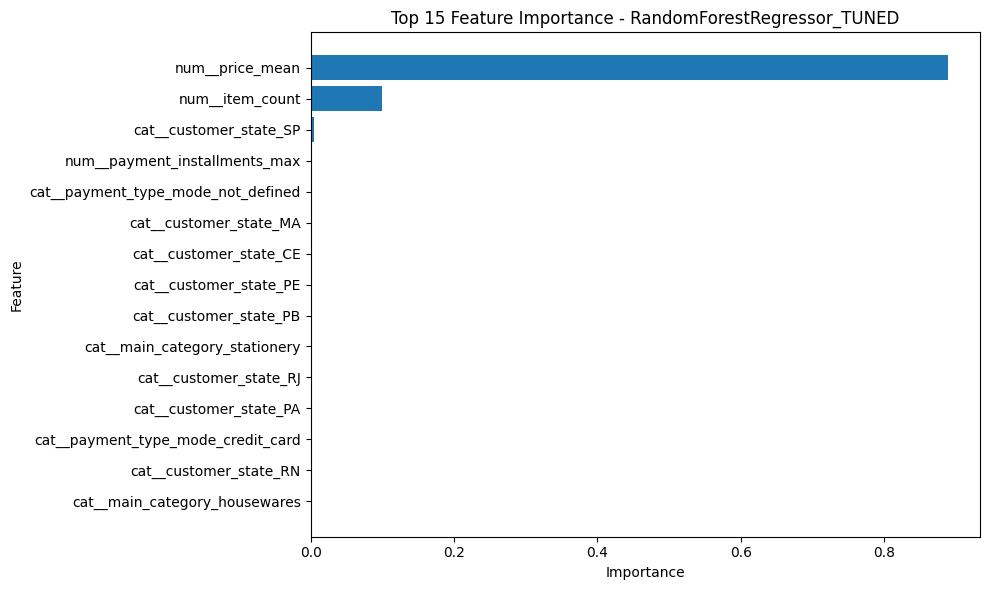

Đã lưu: ..\artifacts\plots\feature_importance_selected_regressor.png


In [24]:
# =========================
# FEATURE IMPORTANCE / COEFFICIENT MAGNITUDE
# =========================
def get_inner_pipeline(fitted_estimator):
    if isinstance(fitted_estimator, TransformedTargetRegressor):
        return fitted_estimator.regressor_
    return fitted_estimator

inner_pipe = get_inner_pipeline(selected_eval_estimator)
fitted_preprocessor = inner_pipe.named_steps["preprocessor"]
fitted_selector = inner_pipe.named_steps["selector"]
fitted_model = inner_pipe.named_steps["model"]

all_feature_names = np.array(fitted_preprocessor.get_feature_names_out())
selected_mask = fitted_selector.get_support()
selected_feature_names = all_feature_names[selected_mask]

importance_df = None
feature_importance_csv_path = None

if hasattr(fitted_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": selected_feature_names,
        "importance": fitted_model.feature_importances_
    }).sort_values("importance", ascending=False)

elif hasattr(fitted_model, "coef_"):
    coef_values = np.ravel(fitted_model.coef_)
    importance_df = pd.DataFrame({
        "feature": selected_feature_names,
        "importance": np.abs(coef_values),
        "coefficient": coef_values
    }).sort_values("importance", ascending=False)

if importance_df is not None:
    display(Markdown(f"### Top feature importance - {selected_eval_model_name}"))
    display(importance_df.head(20))

    feature_importance_csv_path = METRIC_DIR / "regression_feature_importance_selected_model.csv"
    importance_df.to_csv(feature_importance_csv_path, index=False)
    print("Đã lưu:", feature_importance_csv_path)

    plt.figure(figsize=(10, 6))
    top_plot_df = importance_df.head(15).iloc[::-1]
    plt.barh(top_plot_df["feature"], top_plot_df["importance"])
    plt.title(f"Top 15 Feature Importance - {selected_eval_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.tight_layout()

    feature_importance_path = PLOT_DIR / "feature_importance_selected_regressor.png"
    plt.savefig(feature_importance_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Đã lưu:", feature_importance_path)
else:
    feature_importance_path = None
    print("Model không hỗ trợ feature importance / coefficient extraction.")


## Cell 24: Lưu model holdout-eval và refit model deployment trên toàn bộ dữ liệu

In [25]:
# =========================
# SAVE MODELS + REFIT ON FULL DATA
# =========================
selected_eval_model_path = MODEL_DIR / "best_regressor_eval_holdout.joblib"
deployment_model_path = MODEL_DIR / "best_regressor_baseline.joblib"
full_fit_model_path = MODEL_DIR / "best_regressor_full_fit.joblib"
schema_path = MODEL_DIR / "regression_input_schema.json"

joblib.dump(selected_eval_estimator, selected_eval_model_path)
print("Đã lưu model holdout-eval:", selected_eval_model_path)

full_fit_estimator = None
if REFIT_FINAL_ON_FULL_DATA:
    full_fit_estimator = clone(selected_eval_estimator)
    full_fit_start = time.time()
    full_fit_estimator.fit(X, y)
    full_fit_time_sec = time.time() - full_fit_start

    joblib.dump(full_fit_estimator, full_fit_model_path)
    joblib.dump(full_fit_estimator, deployment_model_path)

    print("Đã lưu deployment model (compat path):", deployment_model_path)
    print("Đã lưu full-fit model:", full_fit_model_path)
    print("Full-fit time (sec):", round(full_fit_time_sec, 4))
else:
    full_fit_time_sec = None
    joblib.dump(selected_eval_estimator, deployment_model_path)
    print("REFIT_FINAL_ON_FULL_DATA = False -> dùng selected_eval_estimator cho deployment")

input_schema = {
    "target_column": TARGET_COL,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "feature_columns": feature_cols,
    "selected_k_features": int(k_best),
    "use_log_target_global": USE_LOG_TARGET,
    "use_log_target_for_linear": USE_LOG_TARGET_FOR_LINEAR,
    "deployment_model_name": selected_eval_model_name,
    "deployment_model_source": selected_model_source
}

with open(schema_path, "w", encoding="utf-8") as f:
    json.dump(input_schema, f, ensure_ascii=False, indent=2)

print("Đã lưu schema:", schema_path)

# Reload sanity check
loaded_eval_model = joblib.load(selected_eval_model_path)
_ = loaded_eval_model.predict(X_test.head(min(10, len(X_test))))

loaded_deployment_model = joblib.load(deployment_model_path)
_ = loaded_deployment_model.predict(X.head(min(10, len(X))))

print("Reload sanity check: PASS")


Đã lưu model holdout-eval: ..\artifacts\models\best_regressor_eval_holdout.joblib
Đã lưu deployment model (compat path): ..\artifacts\models\best_regressor_baseline.joblib
Đã lưu full-fit model: ..\artifacts\models\best_regressor_full_fit.joblib
Full-fit time (sec): 31.2636
Đã lưu schema: ..\artifacts\models\regression_input_schema.json
Reload sanity check: PASS


## Cell 25: Lưu dự đoán holdout test của model được chọn

In [26]:
# =========================
# LƯU PREDICTION TRÊN HOLDOUT TEST
# =========================
test_output = X_test.copy().reset_index(drop=True)
test_output["y_true"] = selected_pred_df["y_true"].values
test_output["y_pred"] = selected_pred_df["y_pred"].values
test_output["residual"] = selected_pred_df["residual"].values
test_output["abs_error"] = selected_pred_df["abs_error"].values

test_output_path = PRED_DIR / "selected_regressor_holdout_predictions.csv"
test_output.to_csv(test_output_path, index=False)

print("Đã lưu:", test_output_path)
display(test_output.head())


Đã lưu: ..\artifacts\predictions\selected_regressor_holdout_predictions.csv


,item_count,unique_products,unique_sellers,price_mean,payment_installments_max,purchase_year,purchase_month,purchase_day,purchase_hour,purchase_dayofweek,customer_state,main_category,payment_type_mode,y_true,y_pred,residual,abs_error
0,1.0,1.0,1.0,231.70,1.0,2017,11,24,23,4,SC,cool_stuff,credit_card,249.08,257.578177,-8.498177,8.498177
1,1.0,1.0,1.0,109.90,5.0,2017,11,25,9,5,PR,construction_tools_construction,credit_card,125.42,132.281158,-6.861158,6.861158
2,1.0,1.0,1.0,15.00,1.0,2017,11,6,15,0,RJ,toys,boleto,30.10,30.764645,-0.664645,0.664645
3,1.0,1.0,1.0,229.99,1.0,2017,8,30,21,2,RJ,cool_stuff,boleto,256.05,257.222804,-1.172804,1.172804
4,1.0,1.0,1.0,108.90,6.0,2017,8,10,21,3,PR,sports_leisure,credit_card,128.90,132.609424,-3.709424,3.709424


## Cell 26: Tổng hợp toàn bộ kết quả cuối cùng của notebook regression

In [27]:
# =========================
# TỔNG HỢP CUỐI CÙNG
# =========================
final_summary = {
    "target_column": TARGET_COL,
    "regression_use_case": "Estimate order value from order-time basket/customer/payment features",
    "use_log_target_global": USE_LOG_TARGET,
    "use_log_target_for_linear": USE_LOG_TARGET_FOR_LINEAR,
    "best_baseline_model": best_model_name,
    "best_baseline_rmse": float(best_metrics_row.iloc[0]["rmse"]),
    "best_baseline_mae": float(best_metrics_row.iloc[0]["mae"]),
    "best_baseline_r2": float(best_metrics_row.iloc[0]["r2"]),
    "selected_model_name": selected_eval_model_name,
    "selected_model_source": selected_model_source,
    "selected_holdout_rmse": float(selected_metrics_row.iloc[0]["rmse"]),
    "selected_holdout_mae": float(selected_metrics_row.iloc[0]["mae"]),
    "selected_holdout_r2": float(selected_metrics_row.iloc[0]["r2"]),
    "selected_best_params": selected_best_params,
    "n_numeric_features": len(numeric_features),
    "n_categorical_features": len(categorical_features),
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "baseline_metrics_file": safe_relpath(baseline_metrics_path),
    "cv_all_models_file": safe_relpath(cv_all_models_path),
    "cv_summary_file": safe_relpath(cv_summary_path),
    "grid_search_file": safe_relpath(grid_search_path) if grid_search_path else None,
    "tuning_compare_file": safe_relpath(tuning_compare_path) if tuning_compare_path else None,
    "best_model_file": safe_relpath(deployment_model_path),
    "best_model_eval_file": safe_relpath(selected_eval_model_path),
    "best_model_full_fit_file": safe_relpath(full_fit_model_path),
    "schema_file": safe_relpath(schema_path),
    "prediction_file": safe_relpath(test_output_path),
    "actual_vs_pred_plot": safe_relpath(actual_vs_pred_path),
    "residual_hist_plot": safe_relpath(residual_hist_path),
    "residual_vs_pred_plot": safe_relpath(residual_vs_pred_path),
    "feature_importance_plot": safe_relpath(feature_importance_path) if feature_importance_path else None,
    "feature_importance_table": safe_relpath(feature_importance_csv_path) if feature_importance_csv_path else None,
    "full_fit_time_sec": None if full_fit_time_sec is None else float(full_fit_time_sec)
}

display(Markdown("### Final summary"))
display(pd.DataFrame([final_summary]))

final_summary_path = METRIC_DIR / "regression_final_summary.json"
with open(final_summary_path, "w", encoding="utf-8") as f:
    json.dump(final_summary, f, ensure_ascii=False, indent=2)

print("Đã lưu:", final_summary_path)


### Final summary

,target_column,regression_use_case,use_log_target_global,use_log_target_for_linear,best_baseline_model,best_baseline_rmse,best_baseline_mae,best_baseline_r2,selected_model_name,selected_model_source,...,best_model_eval_file,best_model_full_fit_file,schema_file,prediction_file,actual_vs_pred_plot,residual_hist_plot,residual_vs_pred_plot,feature_importance_plot,feature_importance_table,full_fit_time_sec
0,payment_value_sum,Estimate order value from order-time basket/cu...,True,False,RandomForestRegressor,32.537849,8.322734,0.976104,RandomForestRegressor_TUNED,tuned,...,artifacts/models/best_regressor_eval_holdout.j...,artifacts/models/best_regressor_full_fit.joblib,artifacts/models/regression_input_schema.json,artifacts/predictions/selected_regressor_holdo...,artifacts/plots/actual_vs_pred_selected_regres...,artifacts/plots/residual_hist_selected_regress...,artifacts/plots/residual_vs_pred_selected_regr...,artifacts/plots/feature_importance_selected_re...,artifacts/metrics/regression_feature_importanc...,31.263582


Đã lưu: ..\artifacts\metrics\regression_final_summary.json


## Kết quả đầu ra chính của notebook 04

Notebook này sẽ tạo ra:

### Metrics / summary
- `artifacts/metrics/regression_metrics_baseline.csv`
- `artifacts/metrics/regression_cv_all_models.csv`
- `artifacts/metrics/regression_cv_summary_selected_model.csv`
- `artifacts/metrics/regression_grid_search_best_model.csv` *(nếu bật tuning)*
- `artifacts/metrics/regression_tuning_comparison.csv` *(nếu bật tuning)*
- `artifacts/metrics/regression_feature_importance_selected_model.csv`
- `artifacts/metrics/regression_final_summary.json`

### Models / schema
- `artifacts/models/best_regressor_eval_holdout.joblib`
- `artifacts/models/best_regressor_baseline.joblib` *(compat path cho integration / deployment)*
- `artifacts/models/best_regressor_full_fit.joblib`
- `artifacts/models/regression_input_schema.json`

### Predictions / plots
- `artifacts/predictions/selected_regressor_holdout_predictions.csv`
- `artifacts/plots/actual_vs_pred_selected_regressor.png`
- `artifacts/plots/residual_hist_selected_regressor.png`
- `artifacts/plots/residual_vs_pred_selected_regressor.png`
- `artifacts/plots/feature_importance_selected_regressor.png`

## Ghi chú để viết báo cáo cho đúng notebook
- Target regression: `payment_value_sum`
- Feature selection: `SelectKBest(f_regression)`
- Best deployment model có thể là baseline hoặc tuned, tùy RMSE holdout sau GridSearchCV
- Model deployment cuối cùng được **refit trên toàn bộ dữ liệu đã gán nhãn**


## CHECK-IN — FILE 04: `04_regression_pipeline.ipynb`

### A. THIẾT LẬP BAN ĐẦU
- [x] Hoàn thành import thư viện cho regression pipeline
- [x] Hoàn thành cấu hình cảnh báo
- [x] Hoàn thành khai báo `BASE_DIR`
- [x] Hoàn thành khai báo `PROCESSED_DIR`
- [x] Hoàn thành khai báo `ARTIFACT_DIR`
- [x] Hoàn thành khai báo các thư mục:
  - `MODEL_DIR`
  - `METRIC_DIR`
  - `PLOT_DIR`
  - `PRED_DIR`
- [x] Hoàn thành tạo thư mục output nếu chưa tồn tại
- [x] Hoàn thành khai báo cấu hình chung:
  - `RANDOM_STATE`
  - `TEST_SIZE`
  - `COMPARE_CV_FOLDS`
  - `TUNING_CV_FOLDS`
  - `MAX_SELECTED_FEATURES`
  - `RUN_GRID_SEARCH`
  - `GRID_VERBOSE`
  - `TARGET_COL`
  - `USE_LOG_TARGET`
  - `USE_LOG_TARGET_FOR_LINEAR`
  - `REFIT_FINAL_ON_FULL_DATA`

---

### B. ĐỌC DỮ LIỆU ĐẦU VÀO
- [x] Hoàn thành đọc `orders_base_final.parquet` hoặc `orders_base_final.csv`
- [x] Hoàn thành hiển thị 5 dòng đầu của dữ liệu processed
- [x] Hoàn thành in `Shape`
- [x] Hoàn thành in số lượng cột dữ liệu đầu vào

---

### C. KIỂM TRA CẤU TRÚC CỘT
- [x] Hoàn thành hiển thị danh sách toàn bộ cột của dataset đầu vào

---

### D. CHUẨN HÓA VÀ LÀM SẠCH BIẾN MỤC TIÊU REGRESSION
- [x] Hoàn thành kiểm tra sự tồn tại của `TARGET_COL`
- [x] Hoàn thành ép kiểu numeric cho `payment_value_sum`
- [x] Hoàn thành loại bỏ dòng null của target
- [x] Hoàn thành loại bỏ dòng target âm
- [x] Hoàn thành hiển thị thống kê mô tả của target
- [x] Hoàn thành tính `skewness` của target
- [x] Hoàn thành in số dòng còn lại sau khi làm sạch target

---

### E. KHẢO SÁT PHÂN PHỐI BIẾN MỤC TIÊU
- [x] Hoàn thành vẽ histogram của target ở raw scale
- [x] Hoàn thành vẽ histogram của `log1p(target)` khi bật `USE_LOG_TARGET`

---

### F. CHỌN FEATURE ĐẦU VÀO CHO BASELINE REGRESSION
- [x] Hoàn thành khai báo `numeric_candidates`
- [x] Hoàn thành khai báo `categorical_candidates`
- [x] Hoàn thành khai báo `blocked_cols`
- [x] Hoàn thành lọc `numeric_features`
- [x] Hoàn thành lọc `categorical_features`
- [x] Hoàn thành tạo `feature_cols`
- [x] Hoàn thành hiển thị danh sách numeric features
- [x] Hoàn thành hiển thị danh sách categorical features
- [x] Hoàn thành hiển thị tổng số feature baseline regression

---

### G. TẠO DATASET REGRESSION
- [x] Hoàn thành tạo `regression_df`
- [x] Hoàn thành tạo `X`
- [x] Hoàn thành tạo `y`
- [x] Hoàn thành in shape của `X`
- [x] Hoàn thành in shape của `y`
- [x] Hoàn thành kiểm tra missing values trong `X` trước split

---

### H. CHIA DỮ LIỆU TRAIN / TEST
- [x] Hoàn thành `train_test_split`
- [x] Hoàn thành tạo:
  - `X_train`
  - `X_test`
  - `y_train`
  - `y_test`
- [x] Hoàn thành in shape của train set
- [x] Hoàn thành in shape của test set

---

### I. HÀM HỖ TRỢ CHO PIPELINE / TARGET TRANSFORM / CV
- [x] Hoàn thành khai báo hàm `make_ohe()`
- [x] Hoàn thành khai báo hàm `safe_relpath()`
- [x] Hoàn thành khai báo hàm `use_log_target_for_model()`
- [x] Hoàn thành khai báo hàm `model_param_prefix()`
- [x] Hoàn thành khai báo hàm `make_regression_cv()`
- [x] Hoàn thành khai báo hàm `make_tuning_cv()`

---

### J. XÂY DỰNG PREPROCESSOR CHO BASELINE REGRESSION
- [x] Hoàn thành tạo `numeric_transformer`
- [x] Hoàn thành tạo `categorical_transformer`
- [x] Hoàn thành sử dụng `SimpleImputer(strategy="median")` cho numeric
- [x] Hoàn thành sử dụng `StandardScaler()` cho numeric
- [x] Hoàn thành sử dụng `SimpleImputer(strategy="most_frequent")` cho categorical
- [x] Hoàn thành sử dụng `OneHotEncoder(handle_unknown="ignore")` cho categorical
- [x] Hoàn thành tạo `baseline_preprocessor` bằng `ColumnTransformer`
- [x] Hoàn thành `fit_transform()` trên train set
- [x] Hoàn thành `transform()` trên test set
- [x] Hoàn thành in transformed shape của train
- [x] Hoàn thành in transformed shape của test

---

### K. LẤY TÊN FEATURE SAU PREPROCESSING
- [x] Hoàn thành lấy `feature_names_after_preprocess`
- [x] Hoàn thành tính `k_best`
- [x] Hoàn thành in số feature sau preprocess
- [x] Hoàn thành in giá trị `k_best`
- [x] Hoàn thành hiển thị 20 feature đầu tiên sau preprocess

---

### L. KIỂM TRA NHANH FEATURE SELECTION
- [x] Hoàn thành tạo `selector_probe`
- [x] Hoàn thành dùng `SelectKBest(score_func=f_regression, k=k_best)`
- [x] Hoàn thành fit `selector_probe`
- [x] Hoàn thành tạo `probe_scores`
- [x] Hoàn thành hiển thị top feature theo `f_regression`

---

### M. XÂY DỰNG HÀM TẠO ESTIMATOR REGRESSION
- [x] Hoàn thành khai báo hàm `build_regression_estimator()`
- [x] Hoàn thành xây dựng pipeline gồm:
  - `preprocessor`
  - `selector`
  - `model`
- [x] Hoàn thành sử dụng `SelectKBest(score_func=f_regression, k=k_best)` trong pipeline
- [x] Hoàn thành sử dụng `TransformedTargetRegressor` cho các model có log target

---

### N. KHAI BÁO CÁC MÔ HÌNH BASELINE
- [x] Hoàn thành khai báo `LinearRegression`
- [x] Hoàn thành khai báo `DecisionTreeRegressor`
- [x] Hoàn thành khai báo `RandomForestRegressor`
- [x] Hoàn thành tổng hợp các model vào biến `models`
- [x] Hoàn thành hiển thị cấu hình baseline models

---

### O. XÂY DỰNG HÀM ĐÁNH GIÁ MODEL REGRESSION
- [x] Hoàn thành khai báo hàm `evaluate_regressor()`
- [x] Hoàn thành logic `fit()` estimator
- [x] Hoàn thành logic `predict()` trên test set
- [x] Hoàn thành `clip()` prediction về không âm
- [x] Hoàn thành tính các metric:
  - `mae`
  - `mse`
  - `rmse`
  - `r2`
  - `train_time_sec`
  - `use_log_target`
- [x] Hoàn thành tạo `pred_df`
- [x] Hoàn thành tính:
  - `residual`
  - `abs_error`

---

### P. TRAIN VÀ ĐÁNH GIÁ TOÀN BỘ MODEL BASELINE
- [x] Hoàn thành train `LinearRegression`
- [x] Hoàn thành train `DecisionTreeRegressor`
- [x] Hoàn thành train `RandomForestRegressor`
- [x] Hoàn thành lưu `trained_estimators`
- [x] Hoàn thành lưu `test_predictions`
- [x] Hoàn thành tổng hợp `baseline_results`
- [x] Hoàn thành in metrics của từng model baseline

---

### Q. TỔNG HỢP BẢNG KẾT QUẢ BASELINE
- [x] Hoàn thành tạo `baseline_metrics_df`
- [x] Hoàn thành sort baseline models theo:
  - `rmse`
  - `mae`
  - `r2`
  - `train_time_sec`
- [x] Hoàn thành hiển thị bảng `baseline_metrics_df`
- [x] Hoàn thành lưu `regression_metrics_baseline.csv`

---

### R. CHỌN MÔ HÌNH BASELINE TỐT NHẤT
- [x] Hoàn thành chọn `best_model_name`
- [x] Hoàn thành chọn `best_model_estimator`
- [x] Hoàn thành chọn `best_pred_df`
- [x] Hoàn thành hiển thị holdout test sample của best baseline model
- [x] Hoàn thành hiển thị metrics của best baseline model
- [x] Hoàn thành tạo các biến selected model ban đầu:
  - `selected_eval_model_name`
  - `selected_eval_estimator`
  - `selected_pred_df`
  - `selected_metrics_row`
  - `selected_best_params`
  - `selected_model_source`
  - `selected_is_tuned`

---

### S. GRID SEARCH CHO BASELINE MODEL TỐT NHẤT
- [x] Hoàn thành khai báo hàm `build_tuning_setup()`
- [x] Hoàn thành tạo `param_grid` cho:
  - `LinearRegression`
  - `DecisionTreeRegressor`
  - `RandomForestRegressor`
- [x] Hoàn thành chạy `GridSearchCV`
- [x] Hoàn thành dùng `scoring="neg_root_mean_squared_error"`
- [x] Hoàn thành dùng CV cho tuning
- [x] Hoàn thành lấy:
  - `best_estimator_`
  - `best_score_`
  - `best_params_`
- [x] Hoàn thành đánh giá tuned model trên holdout test
- [x] Hoàn thành tạo `grid_search_results`
- [x] Hoàn thành hiển thị `Grid Search result`
- [x] Hoàn thành tạo bảng so sánh `baseline` vs `tuned`
- [x] Hoàn thành cập nhật model được chọn để deployment nếu tuned tốt hơn baseline
- [x] Hoàn thành lưu:
  - `regression_grid_search_best_model.csv`
  - `regression_tuning_comparison.csv`

---

### T. ACTUAL VS PREDICTED
- [x] Hoàn thành vẽ scatter `Actual vs Predicted`
- [x] Hoàn thành vẽ đường tham chiếu `y = x`
- [x] Hoàn thành lưu `actual_vs_pred_selected_regressor.png`
- [x] Hoàn thành hiển thị metrics của model được chọn

---

### U. RESIDUAL ANALYSIS
- [x] Hoàn thành hiển thị `Residual summary`
- [x] Hoàn thành vẽ histogram residual
- [x] Hoàn thành lưu `residual_hist_selected_regressor.png`
- [x] Hoàn thành vẽ scatter `Residual vs Predicted`
- [x] Hoàn thành lưu `residual_vs_pred_selected_regressor.png`

---

### V. CROSS-VALIDATION
- [x] Hoàn thành cross-validation cho `LinearRegression`
- [x] Hoàn thành cross-validation cho `DecisionTreeRegressor`
- [x] Hoàn thành cross-validation cho `RandomForestRegressor`
- [x] Hoàn thành dùng `cross_validate()` cho toàn bộ model baseline
- [x] Hoàn thành tính các metric CV:
  - `cv_mae_mean`
  - `cv_mae_std`
  - `cv_rmse_mean`
  - `cv_rmse_std`
  - `cv_r2_mean`
  - `cv_r2_std`
  - `use_log_target`
- [x] Hoàn thành tạo `cv_all_models_df`
- [x] Hoàn thành hiển thị bảng so sánh CV của toàn bộ baseline models
- [x] Hoàn thành lưu `regression_cv_all_models.csv`

- [x] Hoàn thành cross-validation cho model được chọn
- [x] Hoàn thành tạo `cv_summary`
- [x] Hoàn thành hiển thị `Cross-validation summary - selected model`
- [x] Hoàn thành lưu `regression_cv_summary_selected_model.csv`

---

### W. FEATURE IMPORTANCE / COEFFICIENT EXTRACTION
- [x] Hoàn thành khai báo hàm `get_inner_pipeline()`
- [x] Hoàn thành lấy:
  - `inner_pipe`
  - `fitted_preprocessor`
  - `fitted_selector`
  - `fitted_model`
- [x] Hoàn thành lấy `all_feature_names`
- [x] Hoàn thành lấy `selected_feature_names`
- [x] Hoàn thành trích xuất feature importance khi model hỗ trợ
- [x] Hoàn thành trích xuất coefficient magnitude khi model hỗ trợ
- [x] Hoàn thành tạo `importance_df`
- [x] Hoàn thành hiển thị top feature importance
- [x] Hoàn thành lưu:
  - `regression_feature_importance_selected_model.csv`
  - `feature_importance_selected_regressor.png`

---

### X. LƯU MODEL VÀ REFIT TRÊN TOÀN BỘ DỮ LIỆU
- [x] Hoàn thành lưu model holdout-eval:
  - `best_regressor_eval_holdout.joblib`
- [x] Hoàn thành refit model deployment trên toàn bộ dữ liệu
- [x] Hoàn thành lưu:
  - `best_regressor_baseline.joblib`
  - `best_regressor_full_fit.joblib`
- [x] Hoàn thành tính `full_fit_time_sec`
- [x] Hoàn thành tạo `regression_input_schema.json`
- [x] Hoàn thành lưu input schema
- [x] Hoàn thành reload sanity check cho model đã lưu
- [x] Hoàn thành xác nhận `Reload sanity check: PASS`

---

### Y. LƯU PREDICTION TRÊN HOLDOUT TEST
- [x] Hoàn thành tạo `test_output`
- [x] Hoàn thành ghi các cột:
  - feature đầu vào
  - `y_true`
  - `y_pred`
  - `residual`
  - `abs_error`
- [x] Hoàn thành lưu `selected_regressor_holdout_predictions.csv`
- [x] Hoàn thành hiển thị sample holdout predictions

---

### Z. TỔNG HỢP CUỐI CÙNG
- [x] Hoàn thành tạo `final_summary`
- [x] Hoàn thành tổng hợp các thông tin:
  - `target_column`
  - `regression_use_case`
  - `use_log_target_global`
  - `use_log_target_for_linear`
  - `best_baseline_model`
  - `best_baseline_rmse`
  - `best_baseline_mae`
  - `best_baseline_r2`
  - `selected_model_name`
  - `selected_model_source`
  - `selected_holdout_rmse`
  - `selected_holdout_mae`
  - `selected_holdout_r2`
  - `selected_best_params`
  - `n_numeric_features`
  - `n_categorical_features`
  - `numeric_features`
  - `categorical_features`
  - file metrics / CV / tuning / model / schema / predictions / plots / feature importance
  - `full_fit_time_sec`
- [x] Hoàn thành hiển thị `Final summary`
- [x] Hoàn thành lưu `regression_final_summary.json`

---

### AA. KẾT QUẢ ĐẦU RA CHÍNH CỦA NOTEBOOK
- [x] Hoàn thành phần **đọc dữ liệu regression đầu vào**
- [x] Hoàn thành phần **chuẩn hóa và làm sạch target**
- [x] Hoàn thành phần **khảo sát phân phối target**
- [x] Hoàn thành phần **chọn feature baseline regression**
- [x] Hoàn thành phần **tạo dataset regression**
- [x] Hoàn thành phần **train/test split**
- [x] Hoàn thành phần **preprocessor cho regression**
- [x] Hoàn thành phần **feature names sau preprocessing**
- [x] Hoàn thành phần **feature selection probe bằng `f_regression`**
- [x] Hoàn thành phần **build estimator cho regression**
- [x] Hoàn thành phần **khai báo 3 model baseline**
- [x] Hoàn thành phần **đánh giá toàn bộ baseline models**
- [x] Hoàn thành phần **bảng kết quả baseline**
- [x] Hoàn thành phần **chọn model baseline tốt nhất**
- [x] Hoàn thành phần **GridSearchCV cho model tốt nhất**
- [x] Hoàn thành phần **Actual vs Predicted plot**
- [x] Hoàn thành phần **Residual analysis**
- [x] Hoàn thành phần **Cross-validation cho tất cả model và selected model**
- [x] Hoàn thành phần **Feature importance / coefficient extraction**
- [x] Hoàn thành phần **save model + refit full data + schema**
- [x] Hoàn thành phần **lưu holdout predictions**
- [x] Hoàn thành phần **final summary artifact**

### Kết luận cuối:
Notebook `04_regression_pipeline.ipynb` đã **hoàn thành** toàn bộ các hạng mục chính thuộc phạm vi **Regression Pipeline, Baseline Comparison, GridSearchCV, Cross-Validation, Residual Analysis, Feature Importance, Model Save/Load, Holdout Predictions, và Final Summary** của riêng file này.